In [14]:
import matplotlib.pyplot as plt
from scipy.io import loadmat
import numpy as np

In [15]:
p1 = "/Users/tizianocausin/Downloads/baby1_220226_AlexNet_RSA.mat"
p_interp = "/Users/tizianocausin/Downloads/baby1_220226_AlexNet_RSAinterpolated.mat"


In [16]:

print(np.sum(np.array([0**2,0**2,3**2, 10**2]))/np.sum(np.array([0,0,3, 10]))**2)


0.6449704142011834


In [17]:
rsa = loadmat(p1)['rsa']
print(rsa.shape)

(22, 50)


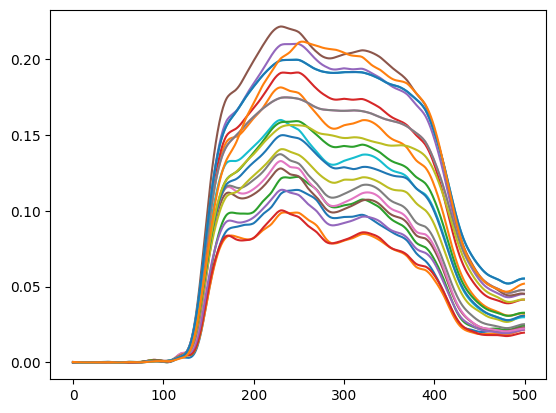

In [18]:
rsa_interp = loadmat(p_interp)['rsasm']
plt.plot(rsa_interp.T);

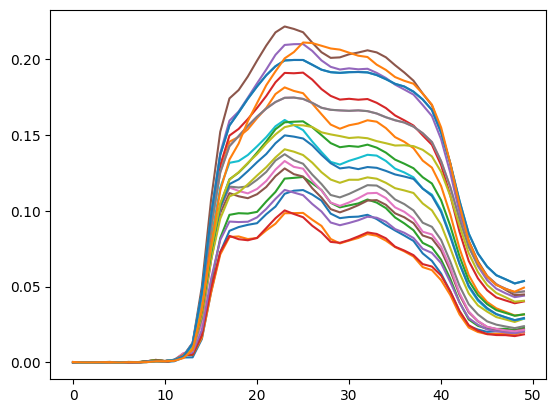

In [19]:
plt.plot(rsa.T);

In [20]:
def softmax(x, T=1.0):
    x = np.array(x) / T
    x = x - np.max(x)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x)

In [21]:
softmax(np.array([5, 5, 2]))

array([0.48785555, 0.48785555, 0.0242889 ])

In [22]:
layers_depths = []
abs_max = []
n_layers, n_timepts = rsa_interp.shape
layers_idx = np.arange(1, n_layers+1)
T = .05
for t in range(n_timepts):
    mods = rsa_interp[:, t]
    layer_depth_t = layers_idx@softmax(mods, T=T)
    abs_max.append(np.argmax(mods))
    layers_depths.append(layer_depth_t)

    


Text(0.5, 0, 'centroid peak latency (ms)')

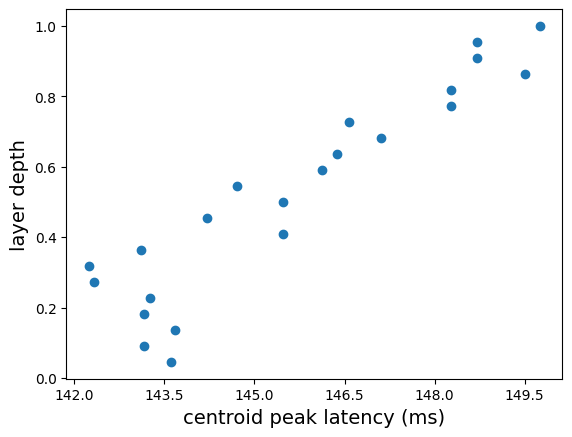

In [25]:
centroids = []
for l in range(n_layers):
    centroids.append(np.average(np.arange(n_timepts), weights=rsa_interp[l,:]))
t_min = min(centroids)
t_max = max(centroids)

n_ticks = 6
ticks = np.round(np.linspace(t_min, t_max, n_ticks))
plt.scatter(centroids, layers_idx/len(layers_idx))
plt.xticks(ticks, ticks/2)
plt.ylabel("layer depth", fontsize=14)
plt.xlabel("centroid peak latency (ms)", fontsize=14)

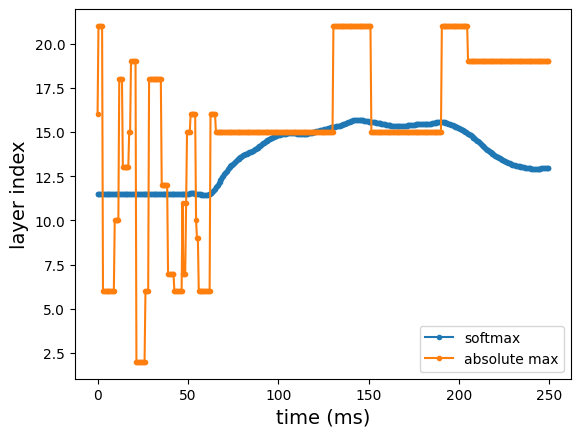

In [53]:
plt.plot(layers_depths, marker=".", label="softmax")
plt.plot(abs_max, marker=".", label="absolute max")
plt.xticks(np.arange(0,n_timepts+1, 100), [0,50, 100, 150, 200, 250])
plt.ylabel("layer index", fontsize=14)
plt.xlabel("time (ms)", fontsize=14)
plt.legend();